In [1]:
# ============================================================
# Industrial 3D Defect Detection
# PyTorch Computer Vision & Volumetric Segmentation
# ============================================================

import sys
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)

print(f"Python:      {sys.version.split()[0]}")
print(f"Platform:    {platform.platform()}")
print(f"PyTorch:     {torch.__version__}")
print(f"CUDA:        {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU:         {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory:  "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GiB"
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device:      {device}")
print("=" * 60)

# Reproducibility
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ENVIRONMENT
Python:      3.12.7
Platform:    Windows-10-10.0.19045-SP0
PyTorch:     2.5.1+cu121
CUDA:        True
GPU:         NVIDIA L40S-48Q
GPU memory:  48.00 GiB
Device:      cuda


In [2]:
# ============================================================
# CELL 2 — EXPERIMENT CONFIGURATION
# ============================================================

from dataclasses import dataclass

@dataclass
class Config:
    # Dataset
    n_builds: int = 120
    depth: int = 64
    height: int = 128
    width: int = 128

    # Build-level defect probability
    defective_build_probability: float = 0.65

    # Intensity characteristics
    background_mean: float = 0.10
    material_mean: float = 0.65
    noise_std: float = 0.04

    # Reproducibility
    seed: int = 42

CFG = Config()

print(CFG)

# Approximate raw float32 volume memory
voxels_per_build = CFG.depth * CFG.height * CFG.width
bytes_per_build = voxels_per_build * 4

print(f"\nVoxels/build: {voxels_per_build:,}")
print(f"Raw image memory/build: {bytes_per_build / 1024**2:.2f} MiB")
print(
    f"Raw image memory for {CFG.n_builds} builds: "
    f"{bytes_per_build * CFG.n_builds / 1024**3:.2f} GiB"
)

Config(n_builds=120, depth=64, height=128, width=128, defective_build_probability=0.65, background_mean=0.1, material_mean=0.65, noise_std=0.04, seed=42)

Voxels/build: 1,048,576
Raw image memory/build: 4.00 MiB
Raw image memory for 120 builds: 0.47 GiB


In [3]:
# ============================================================
# CELL 3 — SYNTHETIC 3D BUILD GENERATOR
# ============================================================

def generate_build(
    depth=64,
    height=128,
    width=128,
    defective=True,
    rng=None
):
    """
    Generate a synthetic layer-by-layer manufacturing volume.

    Returns
    -------
    volume : np.ndarray
        Float32 array with shape [D, H, W].

    mask : np.ndarray
        Binary uint8 ground-truth defect mask [D, H, W].

    metadata : dict
        Information describing simulated defects.
    """

    if rng is None:
        rng = np.random.default_rng()

    # --------------------------------------------------------
    # 1. Background sensor response
    # --------------------------------------------------------
    volume = rng.normal(
        loc=CFG.background_mean,
        scale=CFG.noise_std,
        size=(depth, height, width)
    ).astype(np.float32)

    mask = np.zeros(
        (depth, height, width),
        dtype=np.uint8
    )

    # --------------------------------------------------------
    # 2. Simulated manufactured component
    # --------------------------------------------------------
    yy, xx = np.ogrid[:height, :width]

    centre_y = height // 2
    centre_x = width // 2

    outer_radius = min(height, width) * 0.38

    component = (
        (yy - centre_y) ** 2 +
        (xx - centre_x) ** 2
        <= outer_radius ** 2
    )

    # Give each layer slight process variation
    for z in range(depth):
        layer_variation = rng.normal(0, 0.025)

        material_values = rng.normal(
            loc=CFG.material_mean + layer_variation,
            scale=CFG.noise_std,
            size=component.sum()
        )

        volume[z][component] = material_values

    # --------------------------------------------------------
    # 3. Add volumetric defects
    # --------------------------------------------------------
    defects = []

    if defective:

        n_defects = int(rng.integers(1, 5))

        zz, yy3, xx3 = np.ogrid[
            :depth,
            :height,
            :width
        ]

        for defect_id in range(n_defects):

            cz = int(rng.integers(8, depth - 8))
            cy = int(rng.integers(
                centre_y - int(outer_radius * 0.55),
                centre_y + int(outer_radius * 0.55)
            ))
            cx = int(rng.integers(
                centre_x - int(outer_radius * 0.55),
                centre_x + int(outer_radius * 0.55)
            ))

            rz = int(rng.integers(2, 7))
            ry = int(rng.integers(3, 10))
            rx = int(rng.integers(3, 10))

            # Ellipsoidal defect
            ellipsoid = (
                ((zz - cz) / rz) ** 2 +
                ((yy3 - cy) / ry) ** 2 +
                ((xx3 - cx) / rx) ** 2
                <= 1
            )

            # Keep defects inside manufactured material
            valid_defect = ellipsoid & component[None, :, :]

            mask[valid_defect] = 1

            # Simulate lower sensor intensity in defective region
            defect_intensity = rng.uniform(0.20, 0.45)

            volume[valid_defect] = rng.normal(
                loc=defect_intensity,
                scale=CFG.noise_std,
                size=valid_defect.sum()
            )

            defects.append({
                "id": defect_id,
                "centre": (cz, cy, cx),
                "radius": (rz, ry, rx),
                "intensity": float(defect_intensity),
                "voxels": int(valid_defect.sum())
            })

    volume = np.clip(volume, 0.0, 1.0)

    metadata = {
        "defective": defective,
        "n_defects": len(defects),
        "defects": defects,
        "defect_voxels": int(mask.sum()),
        "total_voxels": int(mask.size),
        "defect_fraction": float(mask.mean())
    }

    return volume, mask, metadata

In [4]:
# ============================================================
# CELL 4 — GENERATE ONE EXAMPLE
# ============================================================

rng = np.random.default_rng(CFG.seed)

volume, mask, metadata = generate_build(
    depth=CFG.depth,
    height=CFG.height,
    width=CFG.width,
    defective=True,
    rng=rng
)

print("Volume shape:", volume.shape)
print("Mask shape:  ", mask.shape)
print("Volume dtype:", volume.dtype)
print("Mask dtype:  ", mask.dtype)

print("\nIntensity range:")
print(f"  min = {volume.min():.4f}")
print(f"  max = {volume.max():.4f}")
print(f"  mean = {volume.mean():.4f}")

print("\nDefect information:")
print(f"  Number of defects: {metadata['n_defects']}")
print(f"  Defect voxels:     {metadata['defect_voxels']:,}")
print(f"  Defect fraction:   {metadata['defect_fraction']:.6f}")

for defect in metadata["defects"]:
    print(
        f"  defect {defect['id']}: "
        f"centre={defect['centre']}, "
        f"radius={defect['radius']}, "
        f"voxels={defect['voxels']:,}"
    )

Volume shape: (64, 128, 128)
Mask shape:   (64, 128, 128)
Volume dtype: float32
Mask dtype:   uint8

Intensity range:
  min = 0.0000
  max = 0.8628
  mean = 0.3479

Defect information:
  Number of defects: 2
  Defect voxels:     1,908
  Defect fraction:   0.001820
  defect 0: centre=(42, 80, 88), radius=(4, 9, 6), voxels=879
  defect 1: centre=(28, 50, 64), radius=(4, 9, 7), voxels=1,029


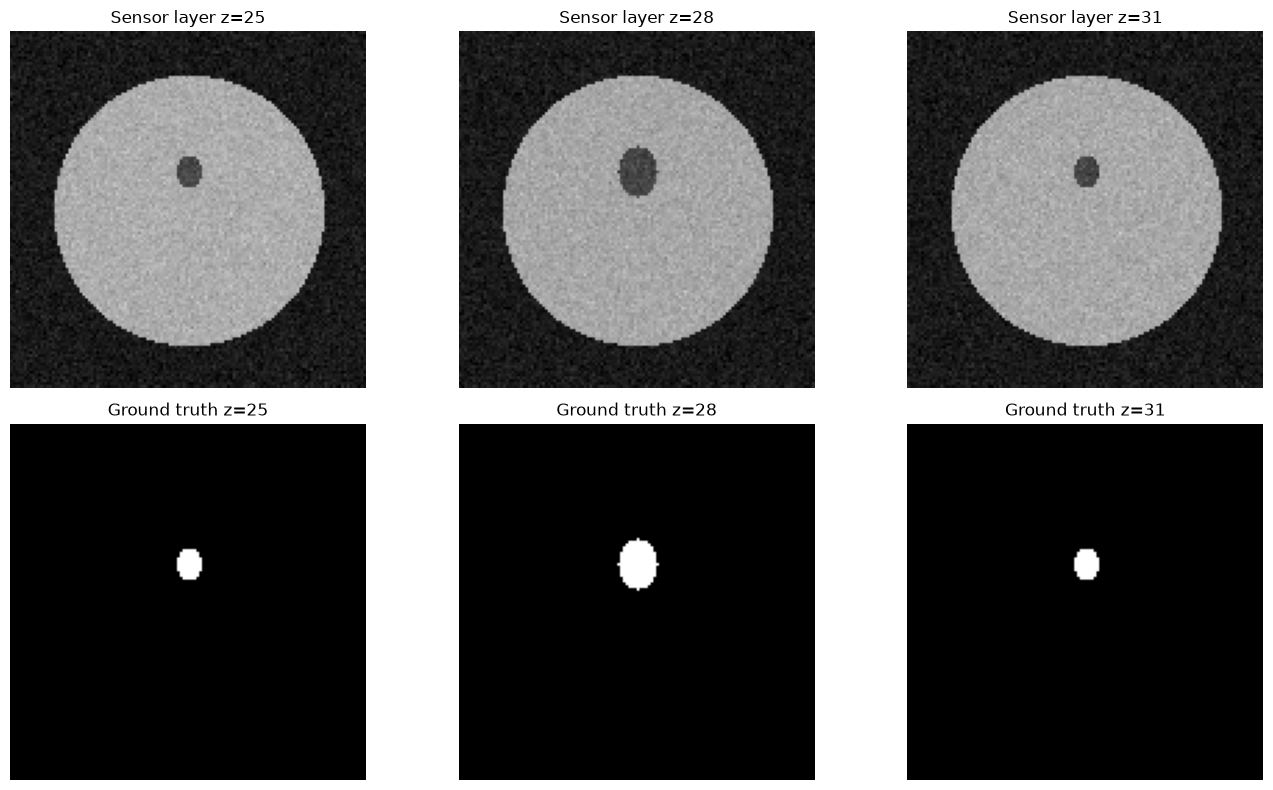

In [5]:
# ============================================================
# CELL 5 — VISUALISE DEFECT THROUGH SUCCESSIVE LAYERS
# ============================================================

largest_defect = max(
    metadata["defects"],
    key=lambda x: x["voxels"]
)

centre_z = largest_defect["centre"][0]

layers = [
    max(0, centre_z - 3),
    centre_z,
    min(CFG.depth - 1, centre_z + 3)
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8)
)

for col, z in enumerate(layers):

    axes[0, col].imshow(
        volume[z],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, col].set_title(f"Sensor layer z={z}")
    axes[0, col].axis("off")

    axes[1, col].imshow(
        mask[z],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, col].set_title(f"Ground truth z={z}")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELL 6 — GENERATE INDEPENDENT SYNTHETIC BUILDS
# ============================================================

from time import perf_counter

dataset_rng = np.random.default_rng(CFG.seed + 100)

volumes = []
masks = []
records = []

start = perf_counter()

for build_id in range(CFG.n_builds):

    defective = (
        dataset_rng.random()
        < CFG.defective_build_probability
    )

    volume_i, mask_i, metadata_i = generate_build(
        depth=CFG.depth,
        height=CFG.height,
        width=CFG.width,
        defective=defective,
        rng=dataset_rng
    )

    volumes.append(volume_i)
    masks.append(mask_i)

    records.append({
        "build_id": build_id,
        "defective": int(defective),
        "n_defects": metadata_i["n_defects"],
        "defect_voxels": metadata_i["defect_voxels"],
        "defect_fraction": metadata_i["defect_fraction"]
    })

elapsed = perf_counter() - start

volumes = np.stack(volumes)
masks = np.stack(masks)

metadata_df = pd.DataFrame(records)

print("=" * 65)
print("DATASET GENERATED")
print("=" * 65)

print("Volumes:", volumes.shape, volumes.dtype)
print("Masks:  ", masks.shape, masks.dtype)

print(f"\nGeneration time: {elapsed:.2f} seconds")

print("\nBuild-level distribution:")
print(metadata_df["defective"].value_counts().sort_index())

print("\nBuild-level percentages:")
print(
    metadata_df["defective"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nDefect statistics:")
print(
    metadata_df[
        ["n_defects", "defect_voxels", "defect_fraction"]
    ].describe()
)

print("\nTotal memory:")
print(
    f"Volumes: {volumes.nbytes / 1024**3:.3f} GiB"
)
print(
    f"Masks:   {masks.nbytes / 1024**3:.3f} GiB"
)

DATASET GENERATED
Volumes: (120, 64, 128, 128) float32
Masks:   (120, 64, 128, 128) uint8

Generation time: 5.96 seconds

Build-level distribution:
defective
0    37
1    83
Name: count, dtype: int64

Build-level percentages:
defective
0    30.83
1    69.17
Name: proportion, dtype: float64

Defect statistics:
        n_defects  defect_voxels  defect_fraction
count  120.000000     120.000000       120.000000
mean     1.658333     973.466667         0.000928
std      1.446502     936.403148         0.000893
min      0.000000       0.000000         0.000000
25%      0.000000       0.000000         0.000000
50%      1.500000     862.000000         0.000822
75%      3.000000    1603.500000         0.001529
max      4.000000    3487.000000         0.003325

Total memory:
Volumes: 0.469 GiB
Masks:   0.117 GiB


In [7]:
print("CFG exists:", "CFG" in globals())
print("generate_build exists:", "generate_build" in globals())
print("metadata_df exists:", "metadata_df" in globals())
print("volumes exists:", "volumes" in globals())
print("masks exists:", "masks" in globals())

CFG exists: True
generate_build exists: True
metadata_df exists: True
volumes exists: True
masks exists: True


In [8]:
# ============================================================
# CELL 8 — BUILD-LEVEL TRAIN / VALIDATION / TEST SPLIT
# NumPy implementation — no sklearn dependency
# ============================================================

build_ids = metadata_df["build_id"].to_numpy()
build_labels = metadata_df["defective"].to_numpy()

rng_split = np.random.default_rng(CFG.seed)

# ------------------------------------------------------------
# Separate build IDs by class
# ------------------------------------------------------------

normal_ids = build_ids[build_labels == 0].copy()
defective_ids = build_ids[build_labels == 1].copy()

rng_split.shuffle(normal_ids)
rng_split.shuffle(defective_ids)


def split_class(ids, train_fraction=0.70, val_fraction=0.15):
    """
    Split IDs from one class into train/validation/test.
    """

    n = len(ids)

    n_train = int(round(n * train_fraction))
    n_val = int(round(n * val_fraction))

    # Everything remaining goes to test
    train = ids[:n_train]
    val = ids[n_train:n_train + n_val]
    test = ids[n_train + n_val:]

    return train, val, test


# ------------------------------------------------------------
# Split each class independently
# ------------------------------------------------------------

normal_train, normal_val, normal_test = split_class(normal_ids)

defect_train, defect_val, defect_test = split_class(defective_ids)


# ------------------------------------------------------------
# Combine classes within each partition
# ------------------------------------------------------------

train_ids = np.concatenate([
    normal_train,
    defect_train
])

val_ids = np.concatenate([
    normal_val,
    defect_val
])

test_ids = np.concatenate([
    normal_test,
    defect_test
])


# Shuffle within each partition
rng_split.shuffle(train_ids)
rng_split.shuffle(val_ids)
rng_split.shuffle(test_ids)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

print("=" * 65)
print("BUILD-LEVEL STRATIFIED SPLIT")
print("=" * 65)

print(f"Train builds:      {len(train_ids)}")
print(f"Validation builds: {len(val_ids)}")
print(f"Test builds:       {len(test_ids)}")

train_set = set(train_ids.tolist())
val_set = set(val_ids.tolist())
test_set = set(test_ids.tolist())

print("\nOverlap checks:")
print("Train ∩ Val: ", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Val ∩ Test:  ", len(val_set & test_set))

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

all_split_ids = train_set | val_set | test_set

assert len(all_split_ids) == CFG.n_builds
assert all_split_ids == set(build_ids.tolist())

print("\n✓ No build leakage.")
print("✓ Every build belongs to exactly one partition.")
print("✓ Stratification performed at build level.")

BUILD-LEVEL STRATIFIED SPLIT
Train builds:      84
Validation builds: 18
Test builds:       18

Overlap checks:
Train ∩ Val:  0
Train ∩ Test: 0
Val ∩ Test:   0

✓ No build leakage.
✓ Every build belongs to exactly one partition.
✓ Stratification performed at build level.


In [9]:
# ============================================================
# CELL 9 — SPLIT SUMMARY
# ============================================================

def summarize_split(name, ids):

    subset = metadata_df[
        metadata_df["build_id"].isin(ids)
    ]

    defective = int(subset["defective"].sum())
    normal = len(subset) - defective

    return {
        "split": name,
        "builds": len(subset),
        "normal_builds": normal,
        "defective_builds": defective,
        "defective_build_pct":
            100 * defective / len(subset)
    }


split_summary = pd.DataFrame([
    summarize_split("Train", train_ids),
    summarize_split("Validation", val_ids),
    summarize_split("Test", test_ids)
])

print(split_summary.to_string(index=False))

     split  builds  normal_builds  defective_builds  defective_build_pct
     Train      84             26                58            69.047619
Validation      18              6                12            66.666667
      Test      18              5                13            72.222222


Slice labels shape: (120, 64)

Example build: 0
Defect-containing layers: [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]

Comparing layers z=36 and z=37
Pixel correlation: 0.9799


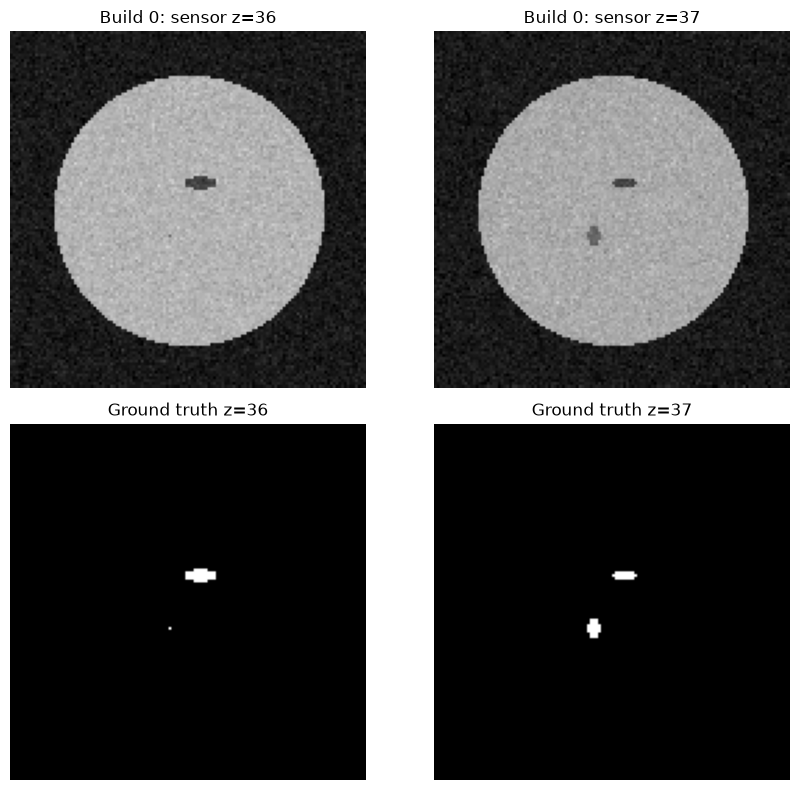

In [11]:
# ============================================================
# CELL 10 — DEMONSTRATE ADJACENT-LAYER SIMILARITY
# ============================================================

# Recreate slice-level labels directly from masks
# Shape:
# masks        = [build, depth, height, width]
# slice_labels = [build, depth]

slice_labels = masks.reshape(
    masks.shape[0],
    masks.shape[1],
    -1
).any(axis=2)

print("Slice labels shape:", slice_labels.shape)

# ------------------------------------------------------------
# Find a defective build
# ------------------------------------------------------------

defective_build_ids = metadata_df.loc[
    metadata_df["defective"] == 1,
    "build_id"
].to_numpy()

example_build = int(defective_build_ids[0])

positive_layers = np.where(
    slice_labels[example_build]
)[0]

print(f"\nExample build: {example_build}")
print(
    "Defect-containing layers:",
    positive_layers.tolist()
)

# ------------------------------------------------------------
# Select two adjacent defect-containing layers
# ------------------------------------------------------------

if len(positive_layers) >= 2:

    middle = len(positive_layers) // 2

    z1 = int(positive_layers[middle])

    # Prefer the next positive layer
    if middle + 1 < len(positive_layers):
        z2 = int(positive_layers[middle + 1])
    else:
        z2 = int(positive_layers[middle - 1])

    layer_1 = volumes[example_build, z1]
    layer_2 = volumes[example_build, z2]

    correlation = np.corrcoef(
        layer_1.ravel(),
        layer_2.ravel()
    )[0, 1]

    print(f"\nComparing layers z={z1} and z={z2}")
    print(f"Pixel correlation: {correlation:.4f}")

    # --------------------------------------------------------
    # Visual comparison
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(9, 8)
    )

    axes[0, 0].imshow(
        layer_1,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, 0].set_title(
        f"Build {example_build}: sensor z={z1}"
    )
    axes[0, 0].axis("off")

    axes[0, 1].imshow(
        layer_2,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, 1].set_title(
        f"Build {example_build}: sensor z={z2}"
    )
    axes[0, 1].axis("off")

    axes[1, 0].imshow(
        masks[example_build, z1],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, 0].set_title(
        f"Ground truth z={z1}"
    )
    axes[1, 0].axis("off")

    axes[1, 1].imshow(
        masks[example_build, z2],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, 1].set_title(
        f"Ground truth z={z2}"
    )
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(
        "This build has fewer than two "
        "defect-containing layers."
    )

In [12]:
# ============================================================
# CELL 11 — FINAL DATASET SANITY CHECK
# ============================================================

print("=" * 65)
print("DATASET SANITY CHECK")
print("=" * 65)

print(f"Volumes:      {volumes.shape}")
print(f"Masks:        {masks.shape}")
print(f"Slice labels: {slice_labels.shape}")

print("\nBuild partitions:")
print(f"Train:      {len(train_ids)}")
print(f"Validation: {len(val_ids)}")
print(f"Test:       {len(test_ids)}")

# Slice statistics
total_slices = slice_labels.size
positive_slices = int(slice_labels.sum())
negative_slices = total_slices - positive_slices

print("\nSlice classification problem:")
print(f"Total slices:     {total_slices:,}")
print(f"Normal slices:    {negative_slices:,}")
print(f"Defective slices: {positive_slices:,}")
print(
    f"Defective prevalence: "
    f"{100 * positive_slices / total_slices:.2f}%"
)

# Voxel statistics
positive_voxels = int(masks.sum())
total_voxels = masks.size

print("\nSegmentation problem:")
print(f"Total voxels:  {total_voxels:,}")
print(f"Defect voxels: {positive_voxels:,}")
print(
    f"Defect prevalence: "
    f"{100 * positive_voxels / total_voxels:.4f}%"
)

# Integrity
assert volumes.shape == (120, 64, 128, 128)
assert masks.shape == volumes.shape
assert slice_labels.shape == (120, 64)

assert len(set(train_ids) & set(val_ids)) == 0
assert len(set(train_ids) & set(test_ids)) == 0
assert len(set(val_ids) & set(test_ids)) == 0

print("\n✓ Dataset integrity checks passed.")

DATASET SANITY CHECK
Volumes:      (120, 64, 128, 128)
Masks:        (120, 64, 128, 128)
Slice labels: (120, 64)

Build partitions:
Train:      84
Validation: 18
Test:       18

Slice classification problem:
Total slices:     7,680
Normal slices:    6,213
Defective slices: 1,467
Defective prevalence: 19.10%

Segmentation problem:
Total voxels:  125,829,120
Defect voxels: 116,816
Defect prevalence: 0.0928%

✓ Dataset integrity checks passed.


In [13]:
# ============================================================
# CELL 12 — PYTORCH SLICE CLASSIFICATION DATASET
# ============================================================

class SliceClassificationDataset(Dataset):
    """
    Converts complete 3D builds into individual 2D slices.

    IMPORTANT:
    Builds have already been separated into train/val/test.
    Therefore slices from the same build cannot cross partitions.
    """

    def __init__(self, volumes, masks, build_ids):
        self.volumes = volumes
        self.masks = masks
        self.build_ids = np.asarray(build_ids)

        self.samples = []

        for build_id in self.build_ids:
            for z in range(volumes.shape[1]):
                self.samples.append(
                    (int(build_id), int(z))
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        build_id, z = self.samples[index]

        image = self.volumes[build_id, z]

        # Defective if ANY voxel in mask is positive
        label = float(
            self.masks[build_id, z].any()
        )

        # [H,W] -> [C,H,W]
        image = torch.from_numpy(
            image.copy()
        ).float().unsqueeze(0)

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return image, label, build_id, z


train_dataset = SliceClassificationDataset(
    volumes,
    masks,
    train_ids
)

val_dataset = SliceClassificationDataset(
    volumes,
    masks,
    val_ids
)

test_dataset = SliceClassificationDataset(
    volumes,
    masks,
    test_ids
)

print("=" * 65)
print("PYTORCH DATASETS")
print("=" * 65)

print(f"Train slices:      {len(train_dataset):,}")
print(f"Validation slices: {len(val_dataset):,}")
print(f"Test slices:       {len(test_dataset):,}")

x, y, build_id, z = train_dataset[0]

print("\nExample:")
print("Image shape:", x.shape)
print("Label:", y.item())
print("Build:", build_id)
print("Layer:", z)

PYTORCH DATASETS
Train slices:      5,376
Validation slices: 1,152
Test slices:       1,152

Example:
Image shape: torch.Size([1, 128, 128])
Label: 0.0
Build: 85
Layer: 0


In [14]:
# ============================================================
# CELL 13 — PYTORCH DATALOADERS
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

images, labels, build_ids_batch, z_batch = next(
    iter(train_loader)
)

print("=" * 65)
print("FIRST MINI-BATCH")
print("=" * 65)

print("Images:", images.shape)
print("Labels:", labels.shape)

print(
    "Positive samples:",
    int(labels.sum())
)

print(
    "Negative samples:",
    len(labels) - int(labels.sum())
)

print(
    "Image range:",
    f"{images.min():.4f}",
    "to",
    f"{images.max():.4f}"
)

FIRST MINI-BATCH
Images: torch.Size([64, 1, 128, 128])
Labels: torch.Size([64])
Positive samples: 14
Negative samples: 50
Image range: 0.0000 to 0.8880


In [15]:
# ============================================================
# CELL 14 — TRAINING CLASS IMBALANCE
# ============================================================

train_slice_labels = []

for build_id in train_ids:
    labels_i = masks[int(build_id)].reshape(
        CFG.depth,
        -1
    ).any(axis=1)

    train_slice_labels.extend(
        labels_i.astype(np.int64)
    )

train_slice_labels = np.asarray(
    train_slice_labels
)

n_positive = int(train_slice_labels.sum())
n_negative = int(
    len(train_slice_labels) - n_positive
)

positive_rate = (
    n_positive / len(train_slice_labels)
)

pos_weight_value = (
    n_negative / n_positive
)

print("=" * 65)
print("TRAINING CLASS BALANCE")
print("=" * 65)

print(f"Training slices: {len(train_slice_labels):,}")
print(f"Normal:          {n_negative:,}")
print(f"Defective:       {n_positive:,}")
print(
    f"Defective rate: {100 * positive_rate:.2f}%"
)
print(
    f"BCE positive-class weight: "
    f"{pos_weight_value:.3f}"
)

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

TRAINING CLASS BALANCE
Training slices: 5,376
Normal:          4,353
Defective:       1,023
Defective rate: 19.03%
BCE positive-class weight: 4.255


In [16]:
# ============================================================
# CELL 15 — 2D CNN DEFECT CLASSIFIER
# ============================================================

class DefectCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # [B,1,128,128]
            nn.Conv2d(
                1, 16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # [B,16,64,64]
            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # [B,32,32,32]
            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # [B,64,16,16]
            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # [B,128,1,1]
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Linear(
            128,
            1
        )

    def forward(self, x):

        x = self.features(x)

        # [B,128,1,1] -> [B,128]
        x = torch.flatten(x, 1)

        # Raw logits
        x = self.classifier(x)

        return x.squeeze(1)


model = DefectCNN().to(device)

n_parameters = sum(
    p.numel()
    for p in model.parameters()
)

n_trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)

print("\n" + "=" * 65)
print(f"Total parameters:     {n_parameters:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"Device:               {device}")

DefectCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affin

In [17]:
# ============================================================
# CELL 16 — GPU FORWARD-PASS SANITY CHECK
# ============================================================

model.eval()

images, labels, _, _ = next(
    iter(train_loader)
)

images = images.to(
    device,
    non_blocking=True
)

labels = labels.to(
    device,
    non_blocking=True
)

with torch.no_grad():

    logits = model(images)

    probabilities = torch.sigmoid(
        logits
    )

print("=" * 65)
print("GPU FORWARD PASS")
print("=" * 65)

print("Input:        ", images.shape)
print("Logits:       ", logits.shape)
print("Probabilities:", probabilities.shape)

print(
    "\nProbability range:",
    f"{probabilities.min().item():.4f}",
    "to",
    f"{probabilities.max().item():.4f}"
)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

print("\n✓ Forward pass successful.")

GPU FORWARD PASS
Input:         torch.Size([64, 1, 128, 128])
Logits:        torch.Size([64])
Probabilities: torch.Size([64])

Probability range: 0.5020 to 0.5024
GPU: NVIDIA L40S-48Q

✓ Forward pass successful.


In [18]:
# ============================================================
# CELL 17 — TRAINING SETUP
# ============================================================

from time import perf_counter

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS = 15

print("Loss:      BCEWithLogitsLoss")
print("Optimizer: AdamW")
print("LR:        0.001")
print("Epochs:   ", EPOCHS)
print("Device:   ", device)


def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0.0
    total_samples = 0
    correct = 0

    for images, labels, _, _ in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        correct += (
            predictions == labels
        ).sum().item()

    return (
        total_loss / total_samples,
        correct / total_samples
    )


@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_probabilities = []
    all_labels = []

    for images, labels, _, _ in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        probabilities = torch.sigmoid(logits)

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_probabilities.append(
            probabilities.cpu()
        )

        all_labels.append(
            labels.cpu()
        )

    probabilities = torch.cat(
        all_probabilities
    ).numpy()

    labels = torch.cat(
        all_labels
    ).numpy().astype(int)

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    tp = int(
        ((predictions == 1) & (labels == 1)).sum()
    )

    tn = int(
        ((predictions == 0) & (labels == 0)).sum()
    )

    fp = int(
        ((predictions == 1) & (labels == 0)).sum()
    )

    fn = int(
        ((predictions == 0) & (labels == 1)).sum()
    )

    accuracy = (
        (tp + tn) /
        max(tp + tn + fp + fn, 1)
    )

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)

    f1 = (
        2 * precision * recall /
        max(precision + recall, 1e-12)
    )

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "probabilities": probabilities,
        "labels": labels
    }


print("\n✓ Training functions ready.")

Loss:      BCEWithLogitsLoss
Optimizer: AdamW
LR:        0.001
Epochs:    15
Device:    cuda

✓ Training functions ready.


In [19]:
# ============================================================
# CELL 18 — TRAIN 2D CNN
# ============================================================

history = []

best_val_loss = float("inf")
best_state = None

start_time = perf_counter()

for epoch in range(1, EPOCHS + 1):

    epoch_start = perf_counter()

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    epoch_seconds = (
        perf_counter() - epoch_start
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]

        best_state = {
            key: value.detach().cpu().clone()
            for key, value
            in model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"acc {val_metrics['accuracy']:.4f} | "
        f"P {val_metrics['precision']:.4f} | "
        f"R {val_metrics['recall']:.4f} | "
        f"F1 {val_metrics['f1']:.4f} | "
        f"{epoch_seconds:.1f}s"
    )

total_time = perf_counter() - start_time

print("\n" + "=" * 70)
print(
    f"Training completed in "
    f"{total_time:.1f} seconds"
)
print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

Epoch 01/15 | train loss 0.8376 | val loss 0.9359 | acc 0.8811 | P 1.0000 | R 0.2674 | F1 0.4219 | 2.3s
Epoch 02/15 | train loss 0.6141 | val loss 3.0952 | acc 0.1623 | P 0.1623 | R 1.0000 | F1 0.2793 | 1.1s
Epoch 03/15 | train loss 0.5345 | val loss 0.8250 | acc 0.2144 | P 0.1706 | R 0.9947 | F1 0.2913 | 1.1s
Epoch 04/15 | train loss 0.4854 | val loss 0.6529 | acc 0.9418 | P 1.0000 | R 0.6417 | F1 0.7818 | 1.1s
Epoch 05/15 | train loss 0.4574 | val loss 1.1682 | acc 0.1693 | P 0.1635 | R 1.0000 | F1 0.2810 | 1.1s
Epoch 06/15 | train loss 0.4316 | val loss 1.3009 | acc 0.8698 | P 1.0000 | R 0.1979 | F1 0.3304 | 1.1s
Epoch 07/15 | train loss 0.4358 | val loss 1.3621 | acc 0.1632 | P 0.1625 | R 1.0000 | F1 0.2795 | 1.1s
Epoch 08/15 | train loss 0.3905 | val loss 15.4410 | acc 0.1623 | P 0.1623 | R 1.0000 | F1 0.2793 | 1.1s
Epoch 09/15 | train loss 0.3140 | val loss 1.0037 | acc 0.9062 | P 1.0000 | R 0.4225 | F1 0.5940 | 1.1s
Epoch 10/15 | train loss 0.2648 | val loss 2.2027 | acc 0.8637 

 epoch  train_loss  train_accuracy  val_loss  val_accuracy  val_precision  val_recall  val_f1
     1      0.8376          0.8447    0.9359        0.8811         1.0000      0.2674  0.4219
     2      0.6141          0.9254    3.0952        0.1623         0.1623      1.0000  0.2793
     3      0.5345          0.9446    0.8250        0.2144         0.1706      0.9947  0.2913
     4      0.4854          0.9444    0.6529        0.9418         1.0000      0.6417  0.7818
     5      0.4574          0.9449    1.1682        0.1693         0.1635      1.0000  0.2810
     6      0.4316          0.9390    1.3009        0.8698         1.0000      0.1979  0.3304
     7      0.4358          0.9541    1.3621        0.1632         0.1625      1.0000  0.2795
     8      0.3905          0.9570   15.4410        0.1623         0.1623      1.0000  0.2793
     9      0.3140          0.9635    1.0037        0.9062         1.0000      0.4225  0.5940
    10      0.2648          0.9635    2.2027        0.8637  

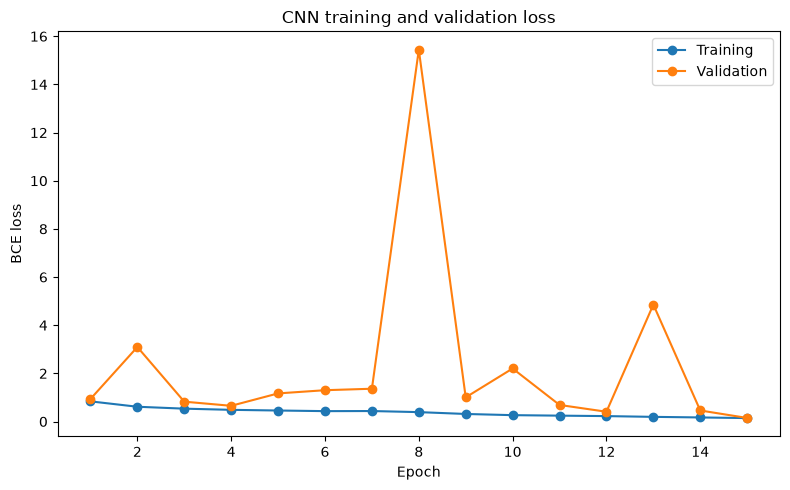

In [20]:
# ============================================================
# CELL 19 — BEST MODEL + LEARNING CURVES
# ============================================================

model.load_state_dict(best_state)
model = model.to(device)

history_df = pd.DataFrame(history)

print(history_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training"
)

ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("BCE loss")
ax.set_title("CNN training and validation loss")
ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CELL 20 — FINAL TEST EVALUATION
# ============================================================

test_metrics = evaluate(
    model,
    test_loader,
    criterion
)

print("=" * 65)
print("LOCKED TEST SET")
print("=" * 65)

print(
    f"Accuracy:  {test_metrics['accuracy']:.4f}"
)
print(
    f"Precision: {test_metrics['precision']:.4f}"
)
print(
    f"Recall:    {test_metrics['recall']:.4f}"
)
print(
    f"F1:        {test_metrics['f1']:.4f}"
)

print("\nConfusion matrix")
print("----------------")
print(
    f"TN = {test_metrics['tn']:4d}    "
    f"FP = {test_metrics['fp']:4d}"
)
print(
    f"FN = {test_metrics['fn']:4d}    "
    f"TP = {test_metrics['tp']:4d}"
)

LOCKED TEST SET
Accuracy:  0.9887
Precision: 0.9880
Recall:    0.9611
F1:        0.9744

Confusion matrix
----------------
TN =  892    FP =    3
FN =   10    TP =  247


In [22]:
# ============================================================
# CELL 21 — 2D SEGMENTATION DATASET
# ============================================================

class SegmentationDataset(Dataset):

    def __init__(self, volumes, masks, build_ids):
        self.volumes = volumes
        self.masks = masks
        self.samples = []

        for build_id in build_ids:
            for z in range(volumes.shape[1]):

                # For initial segmentation training,
                # retain slices containing a defect.
                if masks[int(build_id), z].any():
                    self.samples.append(
                        (int(build_id), int(z))
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        build_id, z = self.samples[idx]

        image = torch.from_numpy(
            self.volumes[build_id, z].copy()
        ).float().unsqueeze(0)

        mask = torch.from_numpy(
            self.masks[build_id, z].copy()
        ).float().unsqueeze(0)

        return image, mask, build_id, z


train_seg_dataset = SegmentationDataset(
    volumes, masks, train_ids
)

val_seg_dataset = SegmentationDataset(
    volumes, masks, val_ids
)

test_seg_dataset = SegmentationDataset(
    volumes, masks, test_ids
)

print("=" * 65)
print("SEGMENTATION DATASETS")
print("=" * 65)

print("Train:", len(train_seg_dataset))
print("Validation:", len(val_seg_dataset))
print("Test:", len(test_seg_dataset))

x, y, build_id, z = train_seg_dataset[0]

print("\nExample image:", x.shape)
print("Example mask: ", y.shape)
print("Defect pixels:", int(y.sum()))
print("Build:", build_id)
print("Layer:", z)

SEGMENTATION DATASETS
Train: 1023
Validation: 187
Test: 257

Example image: torch.Size([1, 128, 128])
Example mask:  torch.Size([1, 128, 128])
Defect pixels: 1
Build: 85
Layer: 20


In [23]:
# ============================================================
# CELL 22 — SEGMENTATION DATALOADERS
# ============================================================

SEG_BATCH_SIZE = 32

train_seg_loader = DataLoader(
    train_seg_dataset,
    batch_size=SEG_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_seg_loader = DataLoader(
    val_seg_dataset,
    batch_size=SEG_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_seg_loader = DataLoader(
    test_seg_dataset,
    batch_size=SEG_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

images, target_masks, _, _ = next(
    iter(train_seg_loader)
)

print("Images:", images.shape)
print("Masks: ", target_masks.shape)
print(
    "Positive pixels:",
    int(target_masks.sum())
)

Images: torch.Size([32, 1, 128, 128])
Masks:  torch.Size([32, 1, 128, 128])
Positive pixels: 2878


In [24]:
# ============================================================
# CELL 23 — 2D U-NET
# ============================================================

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):

    def __init__(self):

        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(
            128, 256
        )

        self.up3 = nn.ConvTranspose2d(
            256, 128, 2, stride=2
        )
        self.dec3 = DoubleConv(
            256, 128
        )

        self.up2 = nn.ConvTranspose2d(
            128, 64, 2, stride=2
        )
        self.dec2 = DoubleConv(
            128, 64
        )

        self.up1 = nn.ConvTranspose2d(
            64, 32, 2, stride=2
        )
        self.dec1 = DoubleConv(
            64, 32
        )

        self.output = nn.Conv2d(
            32, 1, kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        e3 = self.enc3(
            self.pool2(e2)
        )

        b = self.bottleneck(
            self.pool3(e3)
        )

        d3 = self.up3(b)
        d3 = torch.cat(
            [d3, e3],
            dim=1
        )
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat(
            [d2, e2],
            dim=1
        )
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat(
            [d1, e1],
            dim=1
        )
        d1 = self.dec1(d1)

        return self.output(d1)


seg_model = UNet2D().to(device)

parameters = sum(
    p.numel()
    for p in seg_model.parameters()
)

print(seg_model)

print("\nParameters:", f"{parameters:,}")
print("Device:", device)

UNet2D(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
 

In [25]:
# ============================================================
# CELL 24 — SEGMENTATION METRICS
# ============================================================

def dice_score(
    logits,
    targets,
    threshold=0.5,
    eps=1e-7
):

    probs = torch.sigmoid(logits)

    predictions = (
        probs >= threshold
    ).float()

    intersection = (
        predictions * targets
    ).sum(dim=(1, 2, 3))

    denominator = (
        predictions.sum(dim=(1, 2, 3))
        +
        targets.sum(dim=(1, 2, 3))
    )

    dice = (
        (2 * intersection + eps)
        /
        (denominator + eps)
    )

    return dice.mean()


def iou_score(
    logits,
    targets,
    threshold=0.5,
    eps=1e-7
):

    probs = torch.sigmoid(logits)

    predictions = (
        probs >= threshold
    ).float()

    intersection = (
        predictions * targets
    ).sum(dim=(1, 2, 3))

    union = (
        predictions.sum(dim=(1, 2, 3))
        +
        targets.sum(dim=(1, 2, 3))
        -
        intersection
    )

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    return iou.mean()


# GPU forward-pass check

images, target_masks, _, _ = next(
    iter(train_seg_loader)
)

images = images.to(device)
target_masks = target_masks.to(device)

seg_model.eval()

with torch.no_grad():

    logits = seg_model(images)

print("=" * 65)
print("U-NET FORWARD PASS")
print("=" * 65)

print("Input: ", images.shape)
print("Output:", logits.shape)
print("Target:", target_masks.shape)

print(
    "Initial Dice:",
    f"{dice_score(logits, target_masks).item():.4f}"
)

print(
    "Initial IoU:",
    f"{iou_score(logits, target_masks).item():.4f}"
)

print("\n✓ U-Net forward pass successful.")

U-NET FORWARD PASS
Input:  torch.Size([32, 1, 128, 128])
Output: torch.Size([32, 1, 128, 128])
Target: torch.Size([32, 1, 128, 128])
Initial Dice: 0.0092
Initial IoU: 0.0046

✓ U-Net forward pass successful.


In [26]:
# ============================================================
# CELL 25 — SEGMENTATION LOSS
# BCE + SOFT DICE
# ============================================================

def soft_dice_loss(logits, targets, smooth=1.0):

    probabilities = torch.sigmoid(logits)

    probabilities = probabilities.reshape(
        probabilities.size(0), -1
    )

    targets = targets.reshape(
        targets.size(0), -1
    )

    intersection = (
        probabilities * targets
    ).sum(dim=1)

    dice = (
        2.0 * intersection + smooth
    ) / (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
        + smooth
    )

    return 1.0 - dice.mean()


bce_seg = nn.BCEWithLogitsLoss()


def segmentation_loss(logits, targets):

    bce = bce_seg(logits, targets)

    dice = soft_dice_loss(
        logits,
        targets
    )

    total = 0.5 * bce + 0.5 * dice

    return total, bce, dice


# Quick check
seg_model.eval()

images, target_masks, _, _ = next(
    iter(train_seg_loader)
)

images = images.to(device)
target_masks = target_masks.to(device)

with torch.no_grad():

    logits = seg_model(images)

    total, bce, dice = segmentation_loss(
        logits,
        target_masks
    )

print("=" * 65)
print("SEGMENTATION LOSS CHECK")
print("=" * 65)

print(f"BCE:       {bce.item():.4f}")
print(f"Dice loss: {dice.item():.4f}")
print(f"Combined:  {total.item():.4f}")

print("\n✓ Segmentation loss working.")

SEGMENTATION LOSS CHECK
BCE:       0.7082
Dice loss: 0.9906
Combined:  0.8494

✓ Segmentation loss working.


In [27]:
# ============================================================
# CELL 26 — SEGMENTATION TRAINING FUNCTIONS
# ============================================================

def train_seg_epoch(
    model,
    loader,
    optimizer
):

    model.train()

    running_loss = 0.0
    n_samples = 0

    for images, masks_batch, _, _ in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks_batch = masks_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss, _, _ = segmentation_loss(
            logits,
            masks_batch
        )

        loss.backward()

        optimizer.step()

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        n_samples += batch_size

    return running_loss / n_samples


@torch.no_grad()
def evaluate_segmentation(
    model,
    loader
):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    n_samples = 0

    for images, masks_batch, _, _ in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks_batch = masks_batch.to(
            device,
            non_blocking=True
        )

        logits = model(images)

        loss, _, _ = segmentation_loss(
            logits,
            masks_batch
        )

        batch_size = images.size(0)

        dice = dice_score(
            logits,
            masks_batch
        ).item()

        iou = iou_score(
            logits,
            masks_batch
        ).item()

        running_loss += (
            loss.item() * batch_size
        )

        running_dice += (
            dice * batch_size
        )

        running_iou += (
            iou * batch_size
        )

        n_samples += batch_size

    return {
        "loss":
            running_loss / n_samples,

        "dice":
            running_dice / n_samples,

        "iou":
            running_iou / n_samples
    }


print("✓ Training functions ready.")

✓ Training functions ready.


In [28]:
# ============================================================
# CELL 27 — TRAIN 2D U-NET
# ============================================================

seg_optimizer = torch.optim.AdamW(
    seg_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

SEG_EPOCHS = 15

seg_history = []

best_seg_loss = float("inf")
best_seg_state = None

start = perf_counter()

print("=" * 85)
print("TRAINING 2D U-NET")
print("=" * 85)

for epoch in range(1, SEG_EPOCHS + 1):

    epoch_start = perf_counter()

    train_loss = train_seg_epoch(
        seg_model,
        train_seg_loader,
        seg_optimizer
    )

    val_metrics = evaluate_segmentation(
        seg_model,
        val_seg_loader
    )

    elapsed = (
        perf_counter() - epoch_start
    )

    seg_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"]
    })

    if val_metrics["loss"] < best_seg_loss:

        best_seg_loss = val_metrics["loss"]

        best_seg_state = {
            k: v.detach().cpu().clone()
            for k, v
            in seg_model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/{SEG_EPOCHS} | "
        f"train {train_loss:.4f} | "
        f"val {val_metrics['loss']:.4f} | "
        f"Dice {val_metrics['dice']:.4f} | "
        f"IoU {val_metrics['iou']:.4f} | "
        f"{elapsed:.1f}s"
    )

training_time = perf_counter() - start

print("\n" + "=" * 85)

print(
    f"Training time: "
    f"{training_time:.1f} seconds"
)

print(
    f"Best validation loss: "
    f"{best_seg_loss:.4f}"
)

TRAINING 2D U-NET
Epoch 01/15 | train 0.6859 | val 0.7848 | Dice 0.0232 | IoU 0.0119 | 1.4s
Epoch 02/15 | train 0.6029 | val 0.5969 | Dice 0.6546 | IoU 0.5514 | 1.0s
Epoch 03/15 | train 0.5536 | val 0.5434 | Dice 0.6766 | IoU 0.5825 | 1.0s
Epoch 04/15 | train 0.5122 | val 0.5068 | Dice 0.7100 | IoU 0.6312 | 1.0s
Epoch 05/15 | train 0.4713 | val 0.4660 | Dice 0.7911 | IoU 0.7571 | 1.0s
Epoch 06/15 | train 0.4229 | val 0.4134 | Dice 0.8432 | IoU 0.7987 | 1.0s
Epoch 07/15 | train 0.3580 | val 0.3069 | Dice 0.9029 | IoU 0.8936 | 0.9s
Epoch 08/15 | train 0.2771 | val 0.2648 | Dice 0.8581 | IoU 0.8369 | 1.0s
Epoch 09/15 | train 0.1979 | val 0.1916 | Dice 0.9470 | IoU 0.9317 | 1.0s
Epoch 10/15 | train 0.1415 | val 0.1240 | Dice 0.9798 | IoU 0.9774 | 1.0s
Epoch 11/15 | train 0.1043 | val 0.0798 | Dice 0.9762 | IoU 0.9739 | 1.0s
Epoch 12/15 | train 0.0712 | val 0.0850 | Dice 0.9675 | IoU 0.9671 | 1.0s
Epoch 13/15 | train 0.0507 | val 0.0506 | Dice 0.9814 | IoU 0.9783 | 1.0s
Epoch 14/15 | train 

 epoch  train_loss  val_loss  val_dice  val_iou
     1      0.6859    0.7848    0.0232   0.0119
     2      0.6029    0.5969    0.6546   0.5514
     3      0.5536    0.5434    0.6766   0.5825
     4      0.5122    0.5068    0.7100   0.6312
     5      0.4713    0.4660    0.7911   0.7571
     6      0.4229    0.4134    0.8432   0.7987
     7      0.3580    0.3069    0.9029   0.8936
     8      0.2771    0.2648    0.8581   0.8369
     9      0.1979    0.1916    0.9470   0.9317
    10      0.1415    0.1240    0.9798   0.9774
    11      0.1043    0.0798    0.9762   0.9739
    12      0.0712    0.0850    0.9675   0.9671
    13      0.0507    0.0506    0.9814   0.9783
    14      0.0297    0.0268    0.9664   0.9599
    15      0.0208    0.0230    0.9799   0.9777


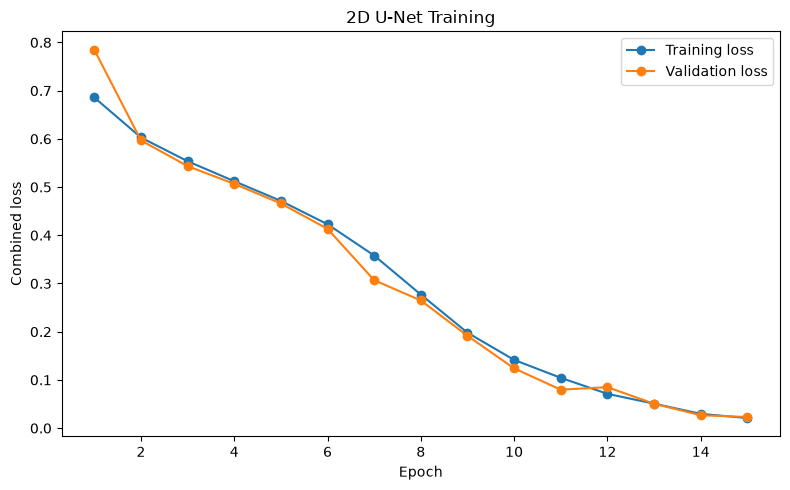

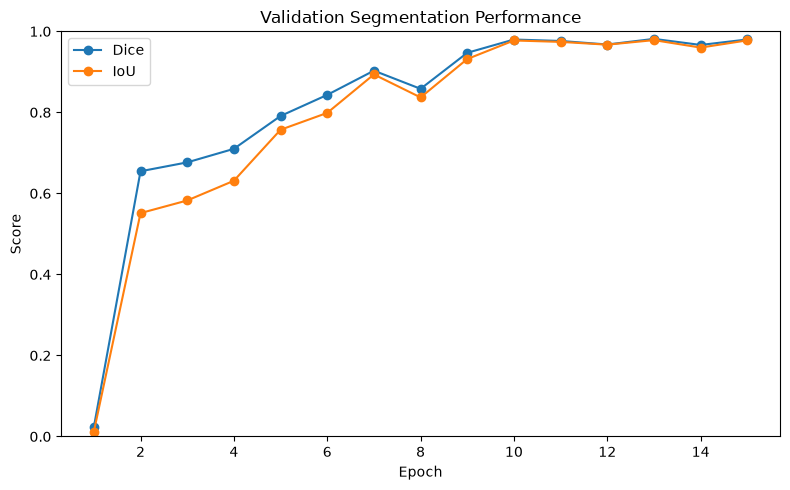

In [29]:
# ============================================================
# CELL 28 — SEGMENTATION LEARNING CURVES
# ============================================================

seg_model.load_state_dict(
    best_seg_state
)

seg_model = seg_model.to(device)

seg_history_df = pd.DataFrame(
    seg_history
)

print(
    seg_history_df
    .round(4)
    .to_string(index=False)
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    seg_history_df["epoch"],
    seg_history_df["train_loss"],
    marker="o",
    label="Training loss"
)

ax.plot(
    seg_history_df["epoch"],
    seg_history_df["val_loss"],
    marker="o",
    label="Validation loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Combined loss")

ax.set_title(
    "2D U-Net Training"
)

ax.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    seg_history_df["epoch"],
    seg_history_df["val_dice"],
    marker="o",
    label="Dice"
)

ax.plot(
    seg_history_df["epoch"],
    seg_history_df["val_iou"],
    marker="o",
    label="IoU"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Score")

ax.set_ylim(0, 1)

ax.set_title(
    "Validation Segmentation Performance"
)

ax.legend()

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# CELL 29 — LOCKED SEGMENTATION TEST SET
# ============================================================

test_seg_metrics = evaluate_segmentation(
    seg_model,
    test_seg_loader
)

print("=" * 65)
print("2D U-NET — LOCKED TEST SET")
print("=" * 65)

print(
    f"Loss: {test_seg_metrics['loss']:.4f}"
)

print(
    f"Dice: {test_seg_metrics['dice']:.4f}"
)

print(
    f"IoU:  {test_seg_metrics['iou']:.4f}"
)

2D U-NET — LOCKED TEST SET
Loss: 0.0214
Dice: 0.9864
IoU:  0.9852


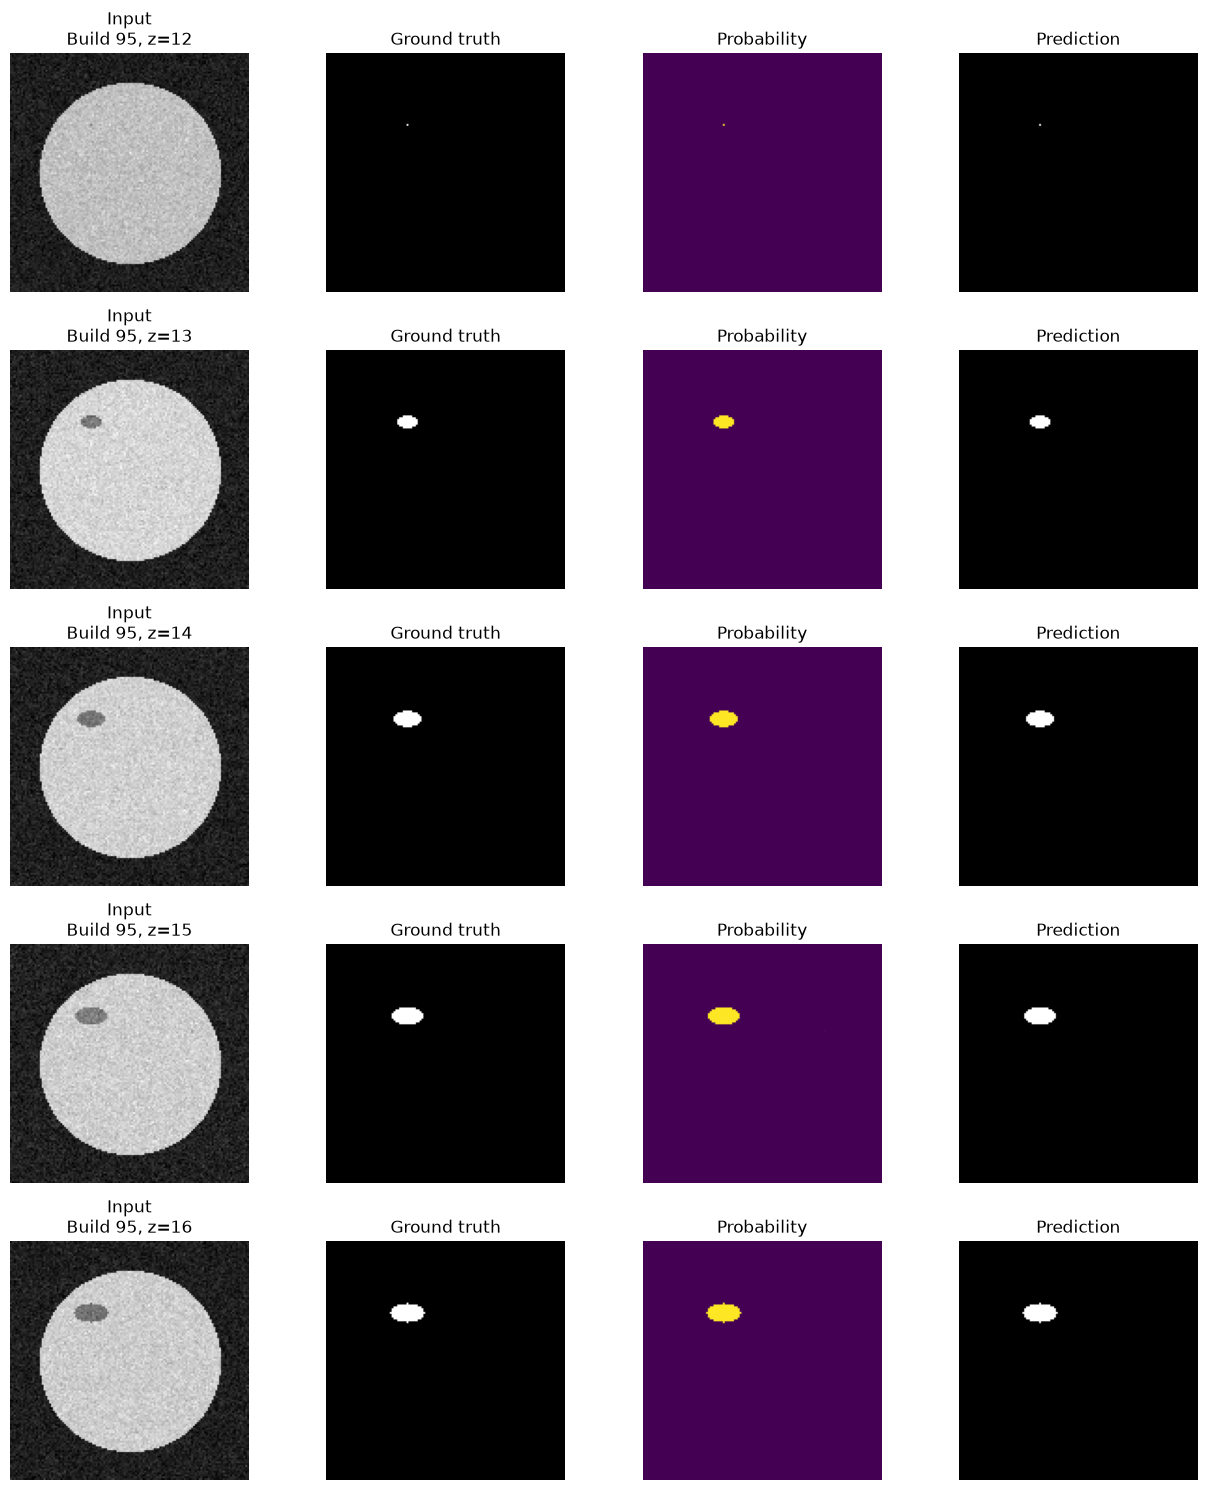

In [31]:
# ============================================================
# CELL 30 — VISUALISE SEGMENTATION PREDICTIONS
# ============================================================

seg_model.eval()

images, targets, build_batch, z_batch = next(
    iter(test_seg_loader)
)

images_gpu = images.to(device)

with torch.no_grad():

    logits = seg_model(
        images_gpu
    )

    probabilities = torch.sigmoid(
        logits
    ).cpu()

predictions = (
    probabilities >= 0.5
).float()

N_SHOW = min(5, len(images))

fig, axes = plt.subplots(
    N_SHOW,
    4,
    figsize=(13, 3 * N_SHOW)
)

if N_SHOW == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )

for i in range(N_SHOW):

    image = images[i, 0].numpy()
    target = targets[i, 0].numpy()
    probability = probabilities[i, 0].numpy()
    prediction = predictions[i, 0].numpy()

    axes[i, 0].imshow(
        image,
        cmap="gray"
    )

    axes[i, 0].set_title(
        f"Input\nBuild {int(build_batch[i])}, "
        f"z={int(z_batch[i])}"
    )

    axes[i, 1].imshow(
        target,
        cmap="gray"
    )

    axes[i, 1].set_title(
        "Ground truth"
    )

    axes[i, 2].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    axes[i, 2].set_title(
        "Probability"
    )

    axes[i, 3].imshow(
        prediction,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[i, 3].set_title(
        "Prediction"
    )

    for j in range(4):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# CELL 31 — NORMAL-SLICE FALSE-POSITIVE TEST
# ============================================================

seg_model.eval()

normal_test_samples = []

for build_id in test_ids:
    for z in range(CFG.depth):
        if not masks[int(build_id), z].any():
            normal_test_samples.append((int(build_id), z))

print("Normal test slices:", len(normal_test_samples))

false_positive_slices = 0
predicted_positive_pixels = 0
total_pixels = 0

with torch.no_grad():

    for build_id, z in normal_test_samples:

        image = torch.from_numpy(
            volumes[build_id, z].copy()
        ).float()[None, None].to(device)

        logits = seg_model(image)

        probability = torch.sigmoid(logits)

        prediction = (
            probability >= 0.5
        )

        positive_pixels = int(
            prediction.sum().item()
        )

        if positive_pixels > 0:
            false_positive_slices += 1

        predicted_positive_pixels += positive_pixels
        total_pixels += prediction.numel()

fp_slice_rate = (
    false_positive_slices /
    max(len(normal_test_samples), 1)
)

fp_pixel_rate = (
    predicted_positive_pixels /
    max(total_pixels, 1)
)

print("=" * 65)
print("NORMAL-SLICE FALSE-POSITIVE ANALYSIS")
print("=" * 65)

print(
    f"Normal slices with any predicted defect: "
    f"{false_positive_slices}"
)

print(
    f"Slice false-positive rate: "
    f"{100 * fp_slice_rate:.2f}%"
)

print(
    f"Pixel false-positive rate: "
    f"{100 * fp_pixel_rate:.6f}%"
)

Normal test slices: 895
NORMAL-SLICE FALSE-POSITIVE ANALYSIS
Normal slices with any predicted defect: 11
Slice false-positive rate: 1.23%
Pixel false-positive rate: 0.000075%


In [33]:
# ============================================================
# CELL 32 — 3D PATCH DATASET
# ============================================================

class Patch3DDataset(Dataset):

    def __init__(
        self,
        volumes,
        masks,
        build_ids,
        patch_size=(16, 64, 64),
        patches_per_build=8,
        seed=42
    ):

        self.volumes = volumes
        self.masks = masks
        self.patch_size = patch_size

        rng = np.random.default_rng(seed)

        self.samples = []

        pd, ph, pw = patch_size

        for build_id in build_ids:

            build_id = int(build_id)

            positive = np.argwhere(
                masks[build_id] > 0
            )

            for _ in range(patches_per_build):

                if len(positive) > 0:

                    cz, cy, cx = positive[
                        rng.integers(len(positive))
                    ]

                else:

                    cz = rng.integers(
                        pd // 2,
                        CFG.depth - pd // 2
                    )

                    cy = rng.integers(
                        ph // 2,
                        CFG.height - ph // 2
                    )

                    cx = rng.integers(
                        pw // 2,
                        CFG.width - pw // 2
                    )

                z0 = np.clip(
                    cz - pd // 2,
                    0,
                    CFG.depth - pd
                )

                y0 = np.clip(
                    cy - ph // 2,
                    0,
                    CFG.height - ph
                )

                x0 = np.clip(
                    cx - pw // 2,
                    0,
                    CFG.width - pw
                )

                self.samples.append(
                    (
                        build_id,
                        int(z0),
                        int(y0),
                        int(x0)
                    )
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        build_id, z, y, x = self.samples[idx]

        pd, ph, pw = self.patch_size

        image = self.volumes[
            build_id,
            z:z+pd,
            y:y+ph,
            x:x+pw
        ]

        mask = self.masks[
            build_id,
            z:z+pd,
            y:y+ph,
            x:x+pw
        ]

        image = torch.from_numpy(
            image.copy()
        ).float().unsqueeze(0)

        mask = torch.from_numpy(
            mask.copy()
        ).float().unsqueeze(0)

        return image, mask


train_3d = Patch3DDataset(
    volumes, masks, train_ids,
    seed=CFG.seed
)

val_3d = Patch3DDataset(
    volumes, masks, val_ids,
    seed=CFG.seed + 1
)

test_3d = Patch3DDataset(
    volumes, masks, test_ids,
    seed=CFG.seed + 2
)

print("Train 3D patches:", len(train_3d))
print("Val 3D patches:  ", len(val_3d))
print("Test 3D patches: ", len(test_3d))

x3d, y3d = train_3d[0]

print("\nImage:", x3d.shape)
print("Mask: ", y3d.shape)
print("Defect voxels:", int(y3d.sum()))

Train 3D patches: 672
Val 3D patches:   144
Test 3D patches:  144

Image: torch.Size([1, 16, 64, 64])
Mask:  torch.Size([1, 16, 64, 64])
Defect voxels: 489


In [34]:
# ============================================================
# CELL 33 — 3D DATALOADERS
# ============================================================

train_3d_loader = DataLoader(
    train_3d,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_3d_loader = DataLoader(
    val_3d,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_3d_loader = DataLoader(
    test_3d,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

x, y = next(iter(train_3d_loader))

print("3D batch image:", x.shape)
print("3D batch mask: ", y.shape)

3D batch image: torch.Size([4, 1, 16, 64, 64])
3D batch mask:  torch.Size([4, 1, 16, 64, 64])


In [35]:
# ============================================================
# CELL 34 — COMPACT 3D U-NET
# ============================================================

class DoubleConv3D(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv3d(
                in_c, out_c,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm3d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_c, out_c,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm3d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet3D(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv3D(1, 16)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(16, 32)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(
            32, 64
        )

        self.up2 = nn.ConvTranspose3d(
            64, 32,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv3D(
            64, 32
        )

        self.up1 = nn.ConvTranspose3d(
            32, 16,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv3D(
            32, 16
        )

        self.output = nn.Conv3d(
            16, 1,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        b = self.bottleneck(
            self.pool2(e2)
        )

        d2 = self.up2(b)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.output(d1)


model_3d = UNet3D().to(device)

n_params_3d = sum(
    p.numel()
    for p in model_3d.parameters()
)

print(model_3d)

print(
    "\n3D U-Net parameters:",
    f"{n_params_3d:,}"
)

# Forward-pass sanity check

x, y = next(iter(train_3d_loader))

x = x.to(device)

with torch.no_grad():
    output = model_3d(x)

print("\nInput: ", x.shape)
print("Output:", output.shape)
print("Target:", y.shape)

assert output.shape == y.shape

print("\n✓ 3D forward pass successful.")

UNet3D(
  (enc1): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [36]:
# ============================================================
# CELL 35 — TRAIN 3D U-NET
# ============================================================

optimizer_3d = torch.optim.AdamW(
    model_3d.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS_3D = 10

best_3d_loss = float("inf")
best_3d_state = None

history_3d = []


def dice_3d(logits, targets, eps=1e-7):

    pred = (
        torch.sigmoid(logits) >= 0.5
    ).float()

    intersection = (
        pred * targets
    ).sum(dim=(1,2,3,4))

    denominator = (
        pred.sum(dim=(1,2,3,4))
        +
        targets.sum(dim=(1,2,3,4))
    )

    return (
        (
            2 * intersection + eps
        )
        /
        (
            denominator + eps
        )
    ).mean()


def iou_3d(logits, targets, eps=1e-7):

    pred = (
        torch.sigmoid(logits) >= 0.5
    ).float()

    intersection = (
        pred * targets
    ).sum(dim=(1,2,3,4))

    union = (
        pred.sum(dim=(1,2,3,4))
        +
        targets.sum(dim=(1,2,3,4))
        -
        intersection
    )

    return (
        (intersection + eps)
        /
        (union + eps)
    ).mean()


for epoch in range(1, EPOCHS_3D + 1):

    model_3d.train()

    train_loss = 0.0

    for images, targets in train_3d_loader:

        images = images.to(device)
        targets = targets.to(device)

        optimizer_3d.zero_grad(
            set_to_none=True
        )

        logits = model_3d(images)

        loss, _, _ = segmentation_loss(
            logits,
            targets
        )

        loss.backward()

        optimizer_3d.step()

        train_loss += (
            loss.item() * images.size(0)
        )

    train_loss /= len(train_3d)

    # Validation

    model_3d.eval()

    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for images, targets in val_3d_loader:

            images = images.to(device)
            targets = targets.to(device)

            logits = model_3d(images)

            loss, _, _ = segmentation_loss(
                logits,
                targets
            )

            batch = images.size(0)

            val_loss += (
                loss.item() * batch
            )

            val_dice += (
                dice_3d(
                    logits,
                    targets
                ).item() * batch
            )

            val_iou += (
                iou_3d(
                    logits,
                    targets
                ).item() * batch
            )

    val_loss /= len(val_3d)
    val_dice /= len(val_3d)
    val_iou /= len(val_3d)

    history_3d.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "dice": val_dice,
        "iou": val_iou
    })

    if val_loss < best_3d_loss:

        best_3d_loss = val_loss

        best_3d_state = {
            k: v.detach().cpu().clone()
            for k, v
            in model_3d.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/{EPOCHS_3D} | "
        f"train {train_loss:.4f} | "
        f"val {val_loss:.4f} | "
        f"Dice {val_dice:.4f} | "
        f"IoU {val_iou:.4f}"
    )

print("\n✓ 3D training complete.")

Epoch 01/10 | train 0.6607 | val 0.5776 | Dice 0.9126 | IoU 0.8483
Epoch 02/10 | train 0.4980 | val 0.4415 | Dice 0.9560 | IoU 0.9182
Epoch 03/10 | train 0.3447 | val 0.2935 | Dice 0.9875 | IoU 0.9756
Epoch 04/10 | train 0.2178 | val 0.2061 | Dice 0.9965 | IoU 0.9930
Epoch 05/10 | train 0.1734 | val 0.1789 | Dice 0.9985 | IoU 0.9969
Epoch 06/10 | train 0.1594 | val 0.1677 | Dice 0.9986 | IoU 0.9972
Epoch 07/10 | train 0.1477 | val 0.1328 | Dice 0.9935 | IoU 0.9876
Epoch 08/10 | train 0.0985 | val 0.0268 | Dice 0.9921 | IoU 0.9845
Epoch 09/10 | train 0.0182 | val 0.0055 | Dice 0.9981 | IoU 0.9962
Epoch 10/10 | train 0.0081 | val 0.0037 | Dice 0.9982 | IoU 0.9965

✓ 3D training complete.


In [37]:
# ============================================================
# CELL 36 — LOCKED 3D TEST SET
# ============================================================

model_3d.load_state_dict(
    best_3d_state
)

model_3d = model_3d.to(device)
model_3d.eval()

test_dice = 0.0
test_iou = 0.0

n_test = 0

with torch.no_grad():

    for images, targets in test_3d_loader:

        images = images.to(device)
        targets = targets.to(device)

        logits = model_3d(images)

        batch = images.size(0)

        test_dice += (
            dice_3d(
                logits,
                targets
            ).item() * batch
        )

        test_iou += (
            iou_3d(
                logits,
                targets
            ).item() * batch
        )

        n_test += batch

test_dice /= n_test
test_iou /= n_test

print("=" * 65)
print("3D U-NET — LOCKED TEST SET")
print("=" * 65)

print(f"Dice: {test_dice:.4f}")
print(f"IoU:  {test_iou:.4f}")

3D U-NET — LOCKED TEST SET
Dice: 0.9974
IoU:  0.9948


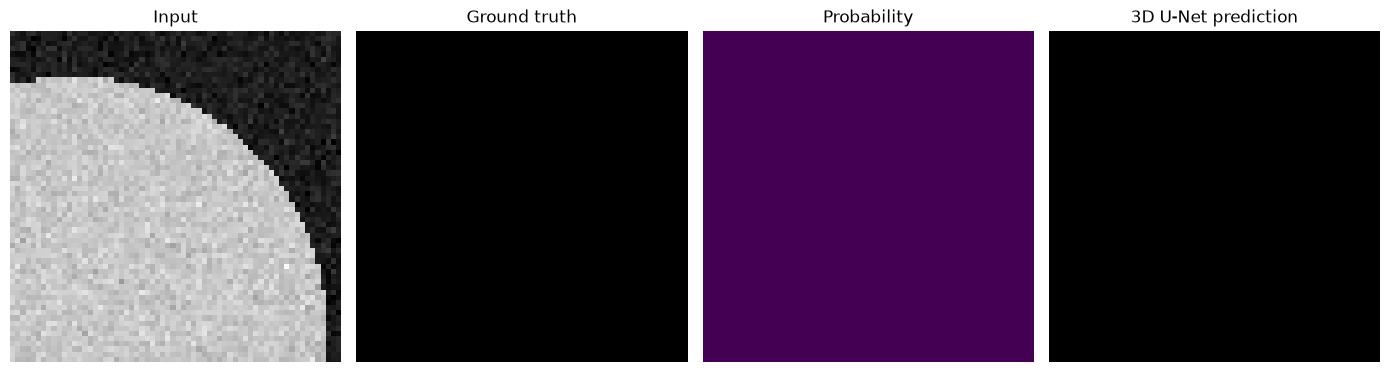

In [38]:
# ============================================================
# CELL 37 — VISUALISE 3D PREDICTION
# ============================================================

image, target = test_3d[0]

model_3d.eval()

with torch.no_grad():

    logits = model_3d(
        image.unsqueeze(0).to(device)
    )

    probability = torch.sigmoid(
        logits
    )[0, 0].cpu().numpy()

prediction = (
    probability >= 0.5
).astype(np.uint8)

image_np = image[0].numpy()
target_np = target[0].numpy()

# Pick layer with largest ground-truth defect
z = np.argmax(
    target_np.sum(axis=(1,2))
)

fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 4)
)

axes[0].imshow(
    image_np[z],
    cmap="gray"
)
axes[0].set_title("Input")

axes[1].imshow(
    target_np[z],
    cmap="gray"
)
axes[1].set_title("Ground truth")

axes[2].imshow(
    probability[z],
    cmap="viridis",
    vmin=0,
    vmax=1
)
axes[2].set_title("Probability")

axes[3].imshow(
    prediction[z],
    cmap="gray"
)
axes[3].set_title("3D U-Net prediction")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# CELL 38 — 3D INFERENCE BENCHMARK
# ============================================================

import time

model_3d.eval()

sample, _ = test_3d[0]

sample = (
    sample
    .unsqueeze(0)
    .to(device)
)

# Warm-up
with torch.no_grad():
    for _ in range(20):
        _ = model_3d(sample)

torch.cuda.synchronize()

N_RUNS = 100

start = time.perf_counter()

with torch.no_grad():

    for _ in range(N_RUNS):
        _ = model_3d(sample)

torch.cuda.synchronize()

elapsed = (
    time.perf_counter() - start
)

latency_ms = (
    elapsed / N_RUNS * 1000
)

throughput = (
    1000 / latency_ms
)

parameter_memory_mb = (
    sum(
        p.numel() * p.element_size()
        for p in model_3d.parameters()
    )
    / 1024**2
)

print("=" * 65)
print("3D INFERENCE BENCHMARK")
print("=" * 65)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

print(
    f"Parameters: "
    f"{n_params_3d:,}"
)

print(
    f"Parameter memory: "
    f"{parameter_memory_mb:.2f} MB"
)

print(
    f"Mean latency: "
    f"{latency_ms:.2f} ms / patch"
)

print(
    f"Throughput: "
    f"{throughput:.2f} patches/s"
)

print(
    "\nInput patch:",
    tuple(sample.shape)
)

3D INFERENCE BENCHMARK
GPU: NVIDIA L40S-48Q
Parameters: 339,889
Parameter memory: 1.30 MB
Mean latency: 2.22 ms / patch
Throughput: 451.16 patches/s

Input patch: (1, 1, 16, 64, 64)
